# Часть 2

## Загрузка данных parquet и подготовка к выгрузке в БД

In [1]:
!pip3 install -q pyspark pyarrow parquet-tools --quiet

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 154.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 7.1 MB/s eta 0:00:00


In [2]:
from pyspark.sql import SparkSession
from pyspark import SparkConf, SparkContext
from pyspark.sql.types import TimestampType
from pyspark.sql.functions import col, sum, count, when, lit, to_date, date_format, row_number, monotonically_increasing_id, unix_timestamp, to_timestamp, current_timestamp, split, element_at
from pyspark.sql.window import Window
import pandas as pd
from datetime import datetime

In [3]:
# Создаём конфигурационный класс с параметрами подключения
conf = (SparkConf().setMaster('local[*]'))

# Создаём точку доступа на кластер. Позволяет использовать RDD API
sc = SparkContext(conf=conf)

# Точка доступа для использования DataFrame API
spark = SparkSession(sc)

# По завершении программы нужно обязательно выполнить остановку подключения для освобождения занятых ресурсов
# sc.stop()

In [4]:
# Считаем файл .parquet и запишем данные в DataFrame
df = spark.read.parquet("chunk_40001_50000.parquet")
df.show(5)

+--------+-------+-----------+--------------------+--------------------+--------------------+--------------------+--------------------+-----------+------------------+-------+----------+-------------+-------------+----------+----------------------+----------------+--------------+-------------+-------------------------+---------+---------------+-------------+--------+--------------------+
|order_id|user_id| user_phone|        address_text|          created_at|             paid_at| delivery_started_at|        delivered_at|canceled_at|      payment_type|item_id|item_title|item_category|item_quantity|item_price|item_canceled_quantity|item_replaced_id|order_discount|item_discount|order_cancellation_reason|driver_id|   driver_phone|delivery_cost|store_id|       store_address|
+--------+-------+-----------+--------------------+--------------------+--------------------+--------------------+--------------------+-----------+------------------+-------+----------+-------------+-------------+-------

Необходимо привести данные в следующий вид:

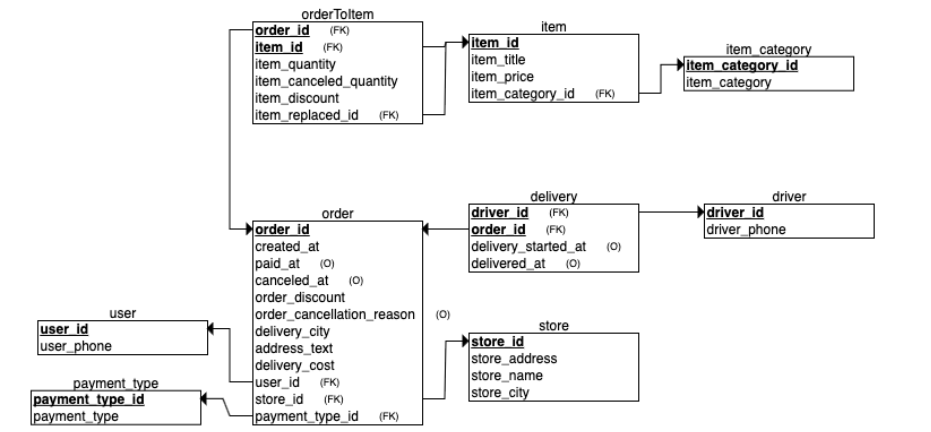

### 1. Таблица `user`

In [5]:
user = df.select(col("user_id").cast("int"), col("user_phone").cast("string")).distinct().orderBy("user_id")
print(f"Таблица user: {user.count()} записей")
user.show(5)

Таблица user: 8306 записей
+-------+------------------+
|user_id|        user_phone|
+-------+------------------+
|     21|       85430779941|
|     37|+7 (114) 990-73-97|
|     60|   8 324 465 67 59|
|    122|       80917210445|
|    156|   8 828 318 70 59|
+-------+------------------+
only showing top 5 rows


### 2. Таблица `driver`

In [6]:
driver = df.select(col("driver_id").cast("int"), col("driver_phone").cast("string")).distinct().orderBy("driver_id")
print(f"Таблица driver: {driver.count()} записей")
driver.show(5)

Таблица driver: 390 записей
+---------+-----------------+
|driver_id|     driver_phone|
+---------+-----------------+
|     1001| 8 (678) 437-9608|
|     1002|  8 323 236 57 28|
|     1003|  +7 053 769 9432|
|     1004| +7 001 327 81 76|
|     1005|+7 (221) 987-6249|
+---------+-----------------+
only showing top 5 rows


### 3. Таблица `store`

In [7]:
store = df.select(col("store_id").cast("int"), col("store_address").cast("string")).distinct().orderBy("store_id")
store = store.withColumn("store_city", element_at(split(col("store_address"), ", "), 2))
store = store.withColumn("store_name", element_at(split(col("store_address"), ", "), 1))
print(f"Таблица store: {store.count()} записей")
store.show()

Таблица store: 3 записей
+--------+--------------------+----------+-------------------+
|store_id|       store_address|store_city|         store_name|
+--------+--------------------+----------+-------------------+
|       1|Сберегайка у дома...|      Орел|  Сберегайка у дома|
|       2|Сберегайка МАКСИМ...|    Москва|Сберегайка МАКСИМУМ|
|       3|Сберегайка у дома...|      Тула|  Сберегайка у дома|
+--------+--------------------+----------+-------------------+



### 4. Таблица `payment_type`

In [9]:
# Для начала нужно создать маппинг типов оплаты и id
payment_types = df.select("payment_type").distinct().collect()
payment_types

[Row(payment_type='Постоплата курьеру'), Row(payment_type='Сразу')]

In [10]:
payment_type_dict = []
id = 0

for row in payment_types:
    payment_type = row['payment_type']
    if payment_type not in [payment_type_dict[i][1] for i in range(len(payment_type_dict))]:
        payment_type_dict.append((id, payment_type))
        id += 1

payment_type_dict

[(0, 'Постоплата курьеру'), (1, 'Сразу')]

In [11]:
payment_type = spark.createDataFrame(payment_type_dict, ["payment_type_id", "payment_type"])
print(f"Таблица payment_type: {payment_type.count()} записей")
payment_type.show(5)

Таблица payment_type: 2 записей
+---------------+------------------+
|payment_type_id|      payment_type|
+---------------+------------------+
|              0|Постоплата курьеру|
|              1|             Сразу|
+---------------+------------------+



### 5. Таблица `item_category`

In [12]:
item_category = df.select(col("item_category").cast("string").alias("item_category")).distinct()

# Добавляем id категорий
window_spec = Window.orderBy("item_category")
item_category = item_category.withColumn("item_category_id", row_number().over(window_spec)).select("item_category_id", "item_category")

print(f"Таблица item_category: {item_category.count()} записей")
item_category.show()

Таблица item_category: 6 записей
+----------------+-----------------+
|item_category_id|    item_category|
+----------------+-----------------+
|               1|Молочные продукты|
|               2|             Мясо|
|               3|          Напитки|
|               4|            Овощи|
|               5|           Фрукты|
|               6|             Хлеб|
+----------------+-----------------+



### 6. Таблица `order`

In [13]:
order = df.select(
        col("order_id").cast("int"),
        to_date(col("created_at")).alias("created_at"),
        to_date(col("paid_at")).alias("paid_at"),
        to_date(col("canceled_at")).alias("canceled_at"),
        col("order_discount").cast("float"),
        col("order_cancellation_reason").cast("string"),
        col("delivery_cost").cast("float"),
        col("address_text").cast("string"),
        col("user_id").cast("int"),
        col("store_id").cast("int")
    ).distinct()

order = order.withColumn("delivery_city", element_at(split(col("address_text"), ", "), 1)
    )
order = order.join(df.select("order_id", "payment_type").distinct(), "order_id")
order = order.join(payment_type, "payment_type").drop("payment_type")

print(f"Таблица Order: {order.count()} записей")
order.show()

Таблица Order: 10000 записей
+--------+----------+----------+-----------+--------------+-------------------------+-------------+--------------------+-------+--------+-------------+---------------+
|order_id|created_at|   paid_at|canceled_at|order_discount|order_cancellation_reason|delivery_cost|        address_text|user_id|store_id|delivery_city|payment_type_id|
+--------+----------+----------+-----------+--------------+-------------------------+-------------+--------------------+-------+--------+-------------+---------------+
|   49573|2025-07-03|2025-07-04| 2025-07-04|           5.0|        Ошибка приложения|        249.0|Москва, ул. Азовс...| 304571|       2|       Москва|              0|
|   42492|2025-09-12|2025-09-12| 2025-09-12|          10.0|       Покупатель отменил|        280.0|Москва, бул. Крас...| 340715|       2|       Москва|              0|
|   40031|2025-06-07|2025-06-07| 2025-06-07|           0.0|       Проблемы с оплатой|        188.0|Орел, ул. Роднико...| 230716|   

### 7. Таблица `item`

In [14]:
# Это если мы добавляем только новые строки
item = df.select(
        col("item_id").cast("int"),
        col("item_title").cast("string"),
        col("item_price").cast("float"),
        col("item_category").cast("string")
    ).distinct()

window_spec = Window.orderBy("item_category")
item_category = item_category.withColumn("item_category_id", row_number().over(window_spec))

# + category_id к товарам
item = item.join(item_category, "item_category", "left")

# + timestamp колонки
current_time = datetime.now()
max_time = datetime(9999, 12, 31, 23, 59, 59)

# Вывод колонок в правильном порядке
item = item.select("item_id", "item_title", "item_price", "item_category_id").orderBy("item_id")

print(f"Таблица Item: {item.count()} записей")
item.show()

Таблица Item: 18 записей
+-------+----------------+----------+----------------+
|item_id|      item_title|item_price|item_category_id|
+-------+----------------+----------+----------------+
|      1|          Яблоки|     335.0|               5|
|      2|          Бананы|     442.0|               5|
|      3|       Апельсины|      99.0|               5|
|      4|          Огурцы|     470.0|               4|
|      5|        Помидоры|     103.0|               4|
|      6|         Капуста|     580.0|               4|
|      7|          Молоко|     219.0|               1|
|      8|           Кефир|     243.0|               1|
|      9|          Творог|     233.0|               1|
|     10|            Кола|     142.0|               3|
|     11|Минеральная вода|     153.0|               3|
|     12|             Сок|     109.0|               3|
|     13|         Свинина|     209.0|               2|
|     14|        Говядина|     567.0|               2|
|     15|          Курица|     471.0|   

### 8. Таблица `orderToItem`

In [15]:
orderToItem = df.select(
        col("order_id").cast("int"),
        col("item_id").cast("int"),
        col("item_quantity").cast("float"),
        col("item_canceled_quantity").cast("float"),
        when(col("item_replaced_id").isNotNull(),
             col("item_replaced_id").cast("int")).otherwise(lit(0)).alias("item_replaced_id"),
        col("item_discount").cast("float")
    ).distinct()

print(f"Таблица orderToItem: {orderToItem.count()} записей")
orderToItem.show()

Таблица orderToItem: 256515 записей
+--------+-------+-------------+----------------------+----------------+-------------+
|order_id|item_id|item_quantity|item_canceled_quantity|item_replaced_id|item_discount|
+--------+-------+-------------+----------------------+----------------+-------------+
|   40023|      4|          4.0|                   0.0|               0|          5.0|
|   40027|     10|         13.0|                   0.0|               0|          5.0|
|   40047|      4|          8.0|                   0.0|               0|          0.0|
|   40070|      8|          1.0|                   0.0|               0|          0.0|
|   40071|      8|          3.0|                   0.0|               0|          0.0|
|   40083|     15|         11.0|                   0.0|               0|         10.0|
|   40087|     16|         12.0|                   0.0|               0|         10.0|
|   40087|      4|          8.0|                   0.0|               0|          0.0|
|   400

### 9. Таблица `delivery`

In [16]:
delivery = df.select(
        col("order_id").cast("int"),
        col("driver_id").cast("int"),
        to_timestamp(col("delivery_started_at")).alias("delivery_started_at"),
        to_timestamp(col("delivered_at")).alias("delivered_at"),
    ).distinct()
delivery.show()

+--------+---------+--------------------+--------------------+
|order_id|driver_id| delivery_started_at|        delivered_at|
+--------+---------+--------------------+--------------------+
|   40493|     1043|2025-08-12 15:23:...|2025-08-12 17:48:...|
|   40553|     2084|2025-08-24 20:54:...|2025-08-24 22:35:...|
|   40561|     3084|2025-07-25 13:27:...|2025-07-25 14:56:...|
|   40678|     1114|2025-01-03 13:00:...|2025-01-03 13:30:...|
|   40810|     1127|2025-10-10 23:57:...|2025-10-11 02:29:...|
|   41091|     2022|2025-03-02 05:37:...|2025-03-02 06:34:...|
|   41095|     3044|2025-06-04 02:42:...|2025-06-04 03:45:...|
|   41272|     1114|2024-12-27 11:25:...|2024-12-27 13:18:...|
|   41553|     2007|2025-10-14 16:55:...|2025-10-14 19:51:...|
|   41577|     3004|2025-06-15 00:09:...|2025-06-15 02:09:...|
|   41829|     2108|2025-10-26 23:50:...|2025-10-27 01:38:...|
|   41910|     3115|2025-01-31 08:51:...|2025-01-31 09:30:...|
|   42257|     1140|2025-05-16 05:21:...|2025-05-16 08:

## Анализ причин отмены доставки

In [17]:
cancel = df.select(
        col("order_id"),
        col("canceled_at"),
        col("delivery_started_at"),
        col("delivered_at"),
        col("delivery_cost"),
        col("order_cancellation_reason")
    ).distinct()
cancel.show()

+--------+--------------------+--------------------+--------------------+-------------+-------------------------+
|order_id|         canceled_at| delivery_started_at|        delivered_at|delivery_cost|order_cancellation_reason|
+--------+--------------------+--------------------+--------------------+-------------+-------------------------+
|   42949|2025-04-01 07:09:...|2025-04-01 02:12:...|2025-04-01 03:39:...|          260|       Проблемы с оплатой|
|   44465|2024-12-20 13:46:...|2024-12-20 09:53:...|2024-12-20 10:42:...|          262|       Покупатель отменил|
|   49825|2025-07-17 17:27:...|2025-07-17 11:20:...|2025-07-17 12:05:...|          186|        Ошибка приложения|
|   40446|2025-04-26 21:07:...|2025-04-26 16:49:...|2025-04-26 18:00:...|          367|       Проблемы с оплатой|
|   41469|2025-04-14 22:04:...|2025-04-14 18:22:...|2025-04-14 19:27:...|          190|       Проблемы с оплатой|
|   44792|2025-01-12 11:13:...|2025-01-12 09:01:...|2025-01-12 10:33:...|          103| 

In [18]:
cancel = cancel.withColumn("is_canceled", when(col("canceled_at").isNotNull(), 1).otherwise(0)
    ).withColumn("is_delivered", when(col("delivered_at").isNotNull(), 1).otherwise(0)
    ).withColumn("has_delivery_cost", when(col("delivery_cost").isNotNull(), 1).otherwise(0)
    ).withColumn("delivery_cost_amount", when(col("delivery_cost").isNotNull(), col("delivery_cost")).otherwise(0)
    )

cancel_agg = cancel.groupBy("is_canceled", "is_delivered").agg(count("*").alias("total_orders"),
        sum("has_delivery_cost").alias("orders_with_delivery_cost"),
        sum("delivery_cost_amount").alias("total_delivery_cost"),
        count(when(col("delivery_cost") > 0, 1)).alias("orders_with_positive_cost")
    ).orderBy("is_canceled", "is_delivered")

cancel_agg.show()

+-----------+------------+------------+-------------------------+-------------------+-------------------------+
|is_canceled|is_delivered|total_orders|orders_with_delivery_cost|total_delivery_cost|orders_with_positive_cost|
+-----------+------------+------------+-------------------------+-------------------+-------------------------+
|          0|           0|         851|                      851|             213008|                      851|
|          0|           1|        7659|                     7659|            1915119|                     7659|
|          1|           0|        1195|                     1195|             303561|                     1195|
|          1|           1|         295|                      295|              73044|                      295|
+-----------+------------+------------+-------------------------+-------------------+-------------------------+



In [19]:
# Тут все про отмененные заказы
cancelled_detail = cancel.filter(col("is_canceled") == 1
    ).groupBy().agg(
        count("*").alias("total_canceled_orders"),
        count(when(col("delivery_cost").isNotNull(), 1)).alias("cancelled_with_delivery_cost"),
        count(when(col("delivery_cost").isNull(), 1)).alias("cancelled_without_delivery_cost"),
        sum(when(col("delivery_cost").isNotNull(), col("delivery_cost"))).alias("total_cost_in_cancelled"),
        count(when((col("delivery_started_at").isNotNull()) & (col("delivery_cost").isNotNull()), 1)).alias("cancelled_after_delivery_start"),
        count(when((col("delivery_started_at").isNull()) & (col("delivery_cost").isNotNull()), 1)).alias("cancelled_before_delivery_start"))

cancelled_detail.show()

+---------------------+----------------------------+-------------------------------+-----------------------+------------------------------+-------------------------------+
|total_canceled_orders|cancelled_with_delivery_cost|cancelled_without_delivery_cost|total_cost_in_cancelled|cancelled_after_delivery_start|cancelled_before_delivery_start|
+---------------------+----------------------------+-------------------------------+-----------------------+------------------------------+-------------------------------+
|                 1490|                        1490|                              0|                 376605|                           526|                            964|
+---------------------+----------------------------+-------------------------------+-----------------------+------------------------------+-------------------------------+



In [20]:
# Что вообще за отмененные заказы с стоимостью доставки
cancel.filter((col("is_canceled") == 1) & (col("delivery_cost").isNotNull())
    ).select("order_id", "canceled_at", "delivery_started_at", "delivered_at",
        "delivery_cost", "order_cancellation_reason").show(10)

+--------+--------------------+--------------------+--------------------+-------------+-------------------------+
|order_id|         canceled_at| delivery_started_at|        delivered_at|delivery_cost|order_cancellation_reason|
+--------+--------------------+--------------------+--------------------+-------------+-------------------------+
|   42949|2025-04-01 07:09:...|2025-04-01 02:12:...|2025-04-01 03:39:...|          260|       Проблемы с оплатой|
|   44465|2024-12-20 13:46:...|2024-12-20 09:53:...|2024-12-20 10:42:...|          262|       Покупатель отменил|
|   49825|2025-07-17 17:27:...|2025-07-17 11:20:...|2025-07-17 12:05:...|          186|        Ошибка приложения|
|   40446|2025-04-26 21:07:...|2025-04-26 16:49:...|2025-04-26 18:00:...|          367|       Проблемы с оплатой|
|   41469|2025-04-14 22:04:...|2025-04-14 18:22:...|2025-04-14 19:27:...|          190|       Проблемы с оплатой|
|   44792|2025-01-12 11:13:...|2025-01-12 09:01:...|2025-01-12 10:33:...|          103| 

In [21]:
# Тут про причины отмены
cancel.filter(col("is_canceled") == 1
        ).groupBy("order_cancellation_reason").agg(count("*").alias("total"),
            count(when(col("delivery_cost").isNotNull(), 1)).alias("with_delivery_cost"),
            sum(when(col("delivery_cost").isNotNull(), col("delivery_cost"))).alias("total_cost")
        ).orderBy("total", ascending=False).show()

+-------------------------+-----+------------------+----------+
|order_cancellation_reason|total|with_delivery_cost|total_cost|
+-------------------------+-----+------------------+----------+
|       Покупатель отменил|  397|               397|    100333|
|       Проблемы с оплатой|  380|               380|     94437|
|        Ошибка приложения|  360|               360|     90852|
|                     NULL|  353|               353|     90983|
+-------------------------+-----+------------------+----------+



## Итоговые таблицы:

In [22]:
user.show()

+-------+------------------+
|user_id|        user_phone|
+-------+------------------+
|     21|       85430779941|
|     37|+7 (114) 990-73-97|
|     60|   8 324 465 67 59|
|    122|       80917210445|
|    156|   8 828 318 70 59|
|    177|    8 491 793 0174|
|    183| 8 (335) 479-67-72|
|    184|+7 (163) 013-16-77|
|    185|   8 895 435 10 70|
|    217|   8 680 834 90 85|
|    419|    8 163 934 8866|
|    462|    8 086 418 9222|
|    477|   +7 749 866 7975|
|    493|+7 (255) 378-63-65|
|    637|   +7 534 284 7699|
|    649| +7 (354) 887-1266|
|    670|  +7 159 716 34 50|
|    708|      +71668054561|
|    719|      +78521933868|
|    737|  8 (549) 541-0404|
+-------+------------------+
only showing top 20 rows


In [23]:
payment_type.show()

+---------------+------------------+
|payment_type_id|      payment_type|
+---------------+------------------+
|              0|Постоплата курьеру|
|              1|             Сразу|
+---------------+------------------+



In [24]:
order.show()

+--------+----------+----------+-----------+--------------+-------------------------+-------------+--------------------+-------+--------+-------------+---------------+
|order_id|created_at|   paid_at|canceled_at|order_discount|order_cancellation_reason|delivery_cost|        address_text|user_id|store_id|delivery_city|payment_type_id|
+--------+----------+----------+-----------+--------------+-------------------------+-------------+--------------------+-------+--------+-------------+---------------+
|   49573|2025-07-03|2025-07-04| 2025-07-04|           5.0|        Ошибка приложения|        249.0|Москва, ул. Азовс...| 304571|       2|       Москва|              0|
|   42492|2025-09-12|2025-09-12| 2025-09-12|          10.0|       Покупатель отменил|        280.0|Москва, бул. Крас...| 340715|       2|       Москва|              0|
|   40031|2025-06-07|2025-06-07| 2025-06-07|           0.0|       Проблемы с оплатой|        188.0|Орел, ул. Роднико...| 230716|       1|         Орел|         

In [25]:
orderToItem.show()

+--------+-------+-------------+----------------------+----------------+-------------+
|order_id|item_id|item_quantity|item_canceled_quantity|item_replaced_id|item_discount|
+--------+-------+-------------+----------------------+----------------+-------------+
|   40023|      4|          4.0|                   0.0|               0|          5.0|
|   40027|     10|         13.0|                   0.0|               0|          5.0|
|   40047|      4|          8.0|                   0.0|               0|          0.0|
|   40070|      8|          1.0|                   0.0|               0|          0.0|
|   40071|      8|          3.0|                   0.0|               0|          0.0|
|   40083|     15|         11.0|                   0.0|               0|         10.0|
|   40087|     16|         12.0|                   0.0|               0|         10.0|
|   40087|      4|          8.0|                   0.0|               0|          0.0|
|   40093|     15|          5.0|           

In [26]:
item.show()

+-------+----------------+----------+----------------+
|item_id|      item_title|item_price|item_category_id|
+-------+----------------+----------+----------------+
|      1|          Яблоки|     335.0|               5|
|      2|          Бананы|     442.0|               5|
|      3|       Апельсины|      99.0|               5|
|      4|          Огурцы|     470.0|               4|
|      5|        Помидоры|     103.0|               4|
|      6|         Капуста|     580.0|               4|
|      7|          Молоко|     219.0|               1|
|      8|           Кефир|     243.0|               1|
|      9|          Творог|     233.0|               1|
|     10|            Кола|     142.0|               3|
|     11|Минеральная вода|     153.0|               3|
|     12|             Сок|     109.0|               3|
|     13|         Свинина|     209.0|               2|
|     14|        Говядина|     567.0|               2|
|     15|          Курица|     471.0|               2|
|     16| 

In [27]:
delivery.show()

+--------+---------+--------------------+--------------------+
|order_id|driver_id| delivery_started_at|        delivered_at|
+--------+---------+--------------------+--------------------+
|   40493|     1043|2025-08-12 15:23:...|2025-08-12 17:48:...|
|   40553|     2084|2025-08-24 20:54:...|2025-08-24 22:35:...|
|   40561|     3084|2025-07-25 13:27:...|2025-07-25 14:56:...|
|   40678|     1114|2025-01-03 13:00:...|2025-01-03 13:30:...|
|   40810|     1127|2025-10-10 23:57:...|2025-10-11 02:29:...|
|   41091|     2022|2025-03-02 05:37:...|2025-03-02 06:34:...|
|   41095|     3044|2025-06-04 02:42:...|2025-06-04 03:45:...|
|   41272|     1114|2024-12-27 11:25:...|2024-12-27 13:18:...|
|   41553|     2007|2025-10-14 16:55:...|2025-10-14 19:51:...|
|   41577|     3004|2025-06-15 00:09:...|2025-06-15 02:09:...|
|   41829|     2108|2025-10-26 23:50:...|2025-10-27 01:38:...|
|   41910|     3115|2025-01-31 08:51:...|2025-01-31 09:30:...|
|   42257|     1140|2025-05-16 05:21:...|2025-05-16 08:

In [28]:
store.show()

+--------+--------------------+----------+-------------------+
|store_id|       store_address|store_city|         store_name|
+--------+--------------------+----------+-------------------+
|       1|Сберегайка у дома...|      Орел|  Сберегайка у дома|
|       2|Сберегайка МАКСИМ...|    Москва|Сберегайка МАКСИМУМ|
|       3|Сберегайка у дома...|      Тула|  Сберегайка у дома|
+--------+--------------------+----------+-------------------+



In [29]:
item_category.show()

+----------------+-----------------+
|item_category_id|    item_category|
+----------------+-----------------+
|               1|Молочные продукты|
|               2|             Мясо|
|               3|          Напитки|
|               4|            Овощи|
|               5|           Фрукты|
|               6|             Хлеб|
+----------------+-----------------+



In [30]:
driver.show()

+---------+-----------------+
|driver_id|     driver_phone|
+---------+-----------------+
|     1001| 8 (678) 437-9608|
|     1002|  8 323 236 57 28|
|     1003|  +7 053 769 9432|
|     1004| +7 001 327 81 76|
|     1005|+7 (221) 987-6249|
|     1006|  8 850 883 22 06|
|     1007|8 (055) 028-00-64|
|     1008|+7 (597) 613-2297|
|     1009|     +71511400390|
|     1010| 8 (674) 510-3018|
|     1011|8 (173) 627-60-67|
|     1012|   8 824 823 7596|
|     1013| +7 560 017 10 05|
|     1014|+7 (805) 729-1462|
|     1015|      82621598557|
|     1016| +7 550 789 33 58|
|     1017|+7 (498) 990-9076|
|     1018|   8 561 331 5137|
|     1019| 8 (577) 394-9944|
|     1020| 8 (841) 658-5197|
+---------+-----------------+
only showing top 20 rows


## Витрина 1

In [31]:
user.createOrReplaceTempView("user")
driver.createOrReplaceTempView("driver")
store.createOrReplaceTempView("store")
payment_type.createOrReplaceTempView("payment_type")
item_category.createOrReplaceTempView("item_category")
order.createOrReplaceTempView("order")
item.createOrReplaceTempView("item")
orderToItem.createOrReplaceTempView("order_to_item")
delivery.createOrReplaceTempView("delivery")

In [32]:
from pyspark.sql import functions as F

SERVICE_ERROR = ["Ошибка приложения", "Проблемы с оплатой"]

order_items = (
    orderToItem.alias("oti")
    .join(order.alias("o"), F.col("o.order_id") == F.col("oti.order_id"), "inner")
    .join(item.alias("i"), F.col("i.item_id") == F.col("oti.item_id"), "inner")
    .join(item.alias("ir"), F.col("ir.item_id") == F.col("oti.item_replaced_id"), "left")

    #фактическое кол-во
    .withColumn(
        "qty_true",
        F.greatest(
            F.coalesce(F.col("oti.item_quantity"), F.lit(0.0)) -
            F.coalesce(F.col("oti.item_canceled_quantity"), F.lit(0.0)),
            F.lit(0.0)))

    #фактическая цена
    .withColumn(
        "price_true",
        F.when(
            F.coalesce(F.col("oti.item_replaced_id"), F.lit(0)) != F.lit(0),
            F.col("ir.item_price")
        ).otherwise(F.col("i.item_price")))

    #скидка на позицию
    .withColumn("item_discount", F.coalesce(F.col("oti.item_discount"), F.lit(0.0)))

    .select(
        F.col("oti.order_id").alias("order_id"),
        F.col("o.created_at").alias("created_at"),
        F.col("o.paid_at").alias("paid_at"),
        F.col("o.canceled_at").alias("canceled_at"),
        F.col("o.order_discount").alias("order_discount"),
        F.col("o.order_cancellation_reason").alias("order_cancellation_reason"),
        F.col("o.user_id").alias("user_id"),
        F.col("o.store_id").alias("store_id"),

        "qty_true",
        "price_true",
        "item_discount",))


amount_expr = (
    F.col("qty_true") * F.col("price_true") *
    (F.lit(1.0) - F.coalesce(F.col("item_discount"), F.lit(0.0)) / F.lit(100.0)) *
    (F.lit(1.0) - F.coalesce(F.col("order_discount"), F.lit(0.0)) / F.lit(100.0)))

order_money = (
    order_items
    .withColumn("dt", F.to_date(F.col("created_at")))
    .groupBy("order_id", "dt", "user_id", "store_id", "paid_at", "canceled_at", "order_cancellation_reason")
    .agg(
        #Оборот
        F.sum(amount_expr).alias("turnover_amount"),

        #Выручка
        F.sum(
            F.when(F.col("paid_at").isNotNull(), amount_expr).otherwise(F.lit(0.0))
        ).alias("revenue_amount"),))

delivery_agg = (
    delivery
    .groupBy("order_id")
    .agg(
        F.max("delivered_at").alias("delivered_at"),
        F.countDistinct("driver_id").alias("drivers_cnt")))

store_dim = (
    store
    .select(
        "store_id",
        "store_name",
        F.col("store_city").alias("city")))

orders_base = (
    order_money.alias("om")
    .join(order.select("order_id", "delivery_cost").alias("o"), "order_id", "inner")
    .join(delivery_agg.alias("da"), "order_id", "left")
    .join(store_dim.alias("sd"), F.col("om.store_id") == F.col("sd.store_id"), "left")

    #расходы на доставку
    .withColumn("delivery_cost", F.coalesce(F.col("o.delivery_cost"), F.lit(0.0)))

    #сколько курьеров было у заказа
    .withColumn("drivers_cnt", F.coalesce(F.col("da.drivers_cnt"), F.lit(0)))

    # прибыль
    .withColumn("profit_amount", F.col("om.revenue_amount") - F.col("delivery_cost"))

    .select(
        F.col("om.order_id").alias("order_id"),
        F.col("om.dt").alias("dt"),
        F.col("om.store_id").alias("store_id"),
        F.col("om.user_id").alias("user_id"),
        F.col("om.paid_at").alias("paid_at"),
        F.col("om.canceled_at").alias("canceled_at"),
        F.col("om.order_cancellation_reason").alias("order_cancellation_reason"),
        F.col("da.delivered_at").alias("delivered_at"),

        "delivery_cost",
        "drivers_cnt",
        F.col("sd.store_name").alias("store_name"),
        F.col("sd.city").alias("city"),

        F.col("om.turnover_amount").alias("turnover_amount"),
        F.col("om.revenue_amount").alias("revenue_amount"),
        "profit_amount",))

active_couriers = (
    order.alias("o")
    .join(delivery.alias("d"), F.col("d.order_id") == F.col("o.order_id"), "inner")
    .join(store_dim.alias("sd"), F.col("sd.store_id") == F.col("o.store_id"), "inner")
    .where(F.col("d.delivered_at").isNotNull())
    .withColumn("dt", F.to_date(F.col("o.created_at")))
    .groupBy("dt",F.col("o.store_id").alias("store_id"), F.col("sd.city").alias("city")).agg(F.countDistinct("d.driver_id").alias("active_couriers")))

paid_orders_cnt = F.countDistinct(
    F.when(F.col("ob.paid_at").isNotNull(), F.col("ob.order_id")))

orders_mart = (
    orders_base.alias("ob")
    .join(
        active_couriers.alias("ac"),
        (F.col("ob.dt") == F.col("ac.dt")) &
        (F.col("ob.store_id") == F.col("ac.store_id")) &
        (F.col("ob.city") == F.col("ac.city")),"left")

    #гранулярность
    .withColumn("year", F.year("ob.dt"))
    .withColumn("month", F.month("ob.dt"))
    .withColumn("day", F.dayofmonth("ob.dt"))

    .groupBy(
        F.col("ob.dt").alias("dt"),
        "year", "month", "day",
        F.col("ob.city").alias("city"),
        F.col("ob.store_id").alias("store_id"),
        F.col("ob.store_name").alias("store_name"),
        F.coalesce(F.col("ac.active_couriers"), F.lit(0)).alias("active_couriers"),)
    .agg(
        #Финансы
        F.sum("ob.turnover_amount").alias("turnover"),
        F.sum("ob.revenue_amount").alias("revenue"),
        F.sum("ob.profit_amount").alias("profit"),
        F.sum("ob.delivery_cost").alias("delivery_cost"),

        #Статусы заказов
        F.countDistinct("ob.order_id").alias("orders_created"),
        F.countDistinct(F.when(F.col("ob.delivered_at").isNotNull(), F.col("ob.order_id"))).alias("orders_delivered"),
        F.countDistinct(F.when(F.col("ob.canceled_at").isNotNull(), F.col("ob.order_id"))).alias("orders_canceled"),

        #Отмены после доставки
        F.countDistinct(
            F.when(
                (F.col("ob.canceled_at").isNotNull()) &
                (F.col("ob.delivered_at").isNotNull()) &
                (F.col("ob.canceled_at") >F.col("ob.delivered_at")),
                F.col("ob.order_id")
            )
        ).alias("cancels_after_delivery"),

        #Отмены по ошибке сервиса
        F.countDistinct(
            F.when(
                (F.col("ob.canceled_at").isNotNull()) &
                (F.col("ob.order_cancellation_reason").isin(SERVICE_ERROR)),
                F.col("ob.order_id")
            )
        ).alias("cancels_service_side"),

        F.countDistinct("ob.user_id").alias("buyers"),

        # для avg_check
        paid_orders_cnt.alias("paid_orders_cnt"),

        #Смена курера
        F.countDistinct(
            F.when(F.col("ob.drivers_cnt") > 1, F.col("ob.order_id"))).alias("orders_with_driver_change"),)

    #Средний чек
    .withColumn(
        "avg_check",
        F.when(F.col("paid_orders_cnt") ==0, F.lit(0.0)).otherwise(F.col("revenue") / F.col("paid_orders_cnt")))

    #Заказов на покупателя
    .withColumn(
        "orders_per_buyer",
        F.when(F.col("buyers") ==0, F.lit(0.0)).otherwise(F.col("orders_created") / F.col("buyers"))
    )

    #Выручка на покупателя
    .withColumn(
        "revenue_per_buyer",
        F.when(F.col("buyers") == 0, F.lit(0.0)).otherwise(F.col("revenue") / F.col("buyers"))).drop("paid_orders_cnt"))

orders_mart.show(5, truncate=False)
orders_mart.createOrReplaceTempView("orders_mart")


+----------+----+-----+---+------+--------+-------------------+---------------+------------------+------------------+------------------+-------------+--------------+----------------+---------------+----------------------+--------------------+------+-------------------------+------------------+----------------+------------------+
|dt        |year|month|day|city  |store_id|store_name         |active_couriers|turnover          |revenue           |profit            |delivery_cost|orders_created|orders_delivered|orders_canceled|cancels_after_delivery|cancels_service_side|buyers|orders_with_driver_change|avg_check         |orders_per_buyer|revenue_per_buyer |
+----------+----+-----+---+------+--------+-------------------+---------------+------------------+------------------+------------------+-------------+--------------+----------------+---------------+----------------------+--------------------+------+-------------------------+------------------+----------------+------------------+
|2025-0

### Витрина с товарами

In [34]:
from pyspark.sql.functions import col, sum, count, when, lit, to_date, date_format, row_number, monotonically_increasing_id, unix_timestamp, to_timestamp, current_timestamp, split, element_at, greatest, coalesce, year, month, dayofmonth, floor, sum as spark_sum, countDistinct


In [35]:
replacement_ids = (
    orderToItem
    .filter(coalesce(col("item_replaced_id"), lit(0)) != 0)
    .select(
        col("order_id").alias("rep_order_id"),
        col("item_replaced_id").alias("replacement_item_id")
    )
    .distinct()
)

In [36]:
order_item_stage = (
    orderToItem.alias("oti")
    .join(order.select("order_id", "created_at", "store_id", "order_discount", "delivery_city").alias("o"), "order_id", "inner")
    .join(item.select("item_id", "item_title", "item_price", "item_category_id").alias("i"), "item_id", "left")
    .join(item_category.select("item_category_id", "item_category").alias("c"), "item_category_id", "left")
    .join(store.select("store_id", "store_address", "store_city", "store_name").alias("s"), col("o.store_id") == col("s.store_id"), "left")
    .join(replacement_ids.alias("r"), (col("order_id") == col("r.rep_order_id")) & (col("item_id") == col("r.replacement_item_id")), "left")
    .withColumn("created_date", col("o.created_at"))
    .withColumn("city", col("o.delivery_city"))
    .withColumn("is_replacement_item", col("r.replacement_item_id").isNotNull())
    .withColumn("is_replaced_item", coalesce(col("oti.item_replaced_id"), lit(0)) != 0)
    .withColumn("qty", coalesce(col("oti.item_quantity"), lit(0.0)))
    .withColumn("qty_canceled", coalesce(col("oti.item_canceled_quantity"), lit(0.0)))
    .withColumn("price", coalesce(col("i.item_price"), lit(0.0)))
    .withColumn("item_disc", coalesce(col("oti.item_discount"), lit(0.0)))
    .withColumn("order_disc", coalesce(col("o.order_discount"), lit(0.0)))
    .withColumn("gross_quantity", when(col("is_replacement_item"), lit(0.0)).otherwise(col("qty")))
    .withColumn("canceled_quantity", col("qty_canceled"))
    .withColumn("net_quantity", greatest(col("qty") - col("qty_canceled"), lit(0.0)))
    .withColumn("has_item_cancellation", when(col("qty_canceled") > 0, lit(1)).otherwise(lit(0)))
    .withColumn("amount_before_discounts", col("net_quantity") * col("price"))
    .withColumn("amount_after_item_discount", col("net_quantity") * col("price") * (lit(1.0) - col("item_disc") / lit(100.0)))
    .withColumn("amount_after_order_discount", col("net_quantity") * col("price") * (lit(1.0) - col("item_disc") / lit(100.0)) * (lit(1.0) - col("order_disc") / lit(100.0)))

    .select(
        "order_id", col("o.created_at").alias("created_at"), "created_date",
        "city", col("o.store_id").alias("store_id"), col("s.store_name").alias("store_name"),
        col("s.store_address").alias("store_address"), col("c.item_category").alias("item_category"),
        "item_id", col("i.item_title").alias("item_title"), "gross_quantity", "canceled_quantity", "net_quantity", "has_item_cancellation",
        "amount_before_discounts", "amount_after_item_discount", "amount_after_order_discount"
    )
)

order_item_stage.cache()
order_item_stage.show(5, truncate=False)

+--------+----------+------------+------+--------+-------------------+----------------------------------------+-------------+-------+-----------+--------------+-----------------+------------+---------------------+-----------------------+--------------------------+---------------------------+
|order_id|created_at|created_date|city  |store_id|store_name         |store_address                           |item_category|item_id|item_title |gross_quantity|canceled_quantity|net_quantity|has_item_cancellation|amount_before_discounts|amount_after_item_discount|amount_after_order_discount|
+--------+----------+------------+------+--------+-------------------+----------------------------------------+-------------+-------+-----------+--------------+-----------------+------------+---------------------+-----------------------+--------------------------+---------------------------+
|49573   |2025-07-03|2025-07-03  |Москва|2       |Сберегайка МАКСИМУМ|Сберегайка МАКСИМУМ, Москва, Тверская 20|Фрукты    

In [37]:
dm_mart = (
    order_item_stage
    .withColumn("year", year(col("created_date")))
    .withColumn("month", month(col("created_date")))
    .withColumn("day", dayofmonth(col("created_date")))
    .withColumn("week_in_month", (floor((col("day") - lit(1)) / lit(7)) + lit(1)).cast("int"))
    .groupBy(
        "year", "month", "week_in_month", "day", "created_date",
        "city", "store_id", "store_name", "store_address",
        "item_category", "item_id", "item_title"
    )
    .agg(
        spark_sum(col("gross_quantity")).alias("items_qty_gross"),
        spark_sum(col("canceled_quantity")).alias("items_qty_canceled"),
        spark_sum(col("net_quantity")).alias("items_qty_net"),
        countDistinct(col("order_id")).alias("orders_with_item"),
        countDistinct(when(col("has_item_cancellation") == 1, col("order_id"))).alias("orders_with_item_cancellation"),
        spark_sum(col("amount_before_discounts")).alias("revenue_before_discounts"),
        spark_sum(col("amount_after_item_discount")).alias("revenue_after_item_discount"),
        spark_sum(col("amount_after_order_discount")).alias("revenue_after_order_discount"),
    )
)

dm_mart.cache()
dm_mart.show(10, truncate=False)

+----+-----+-------------+---+------------+------+--------+-------------------+----------------------------------------+-----------------+-------+----------------+---------------+------------------+-------------+----------------+-----------------------------+------------------------+---------------------------+----------------------------+
|year|month|week_in_month|day|created_date|city  |store_id|store_name         |store_address                           |item_category    |item_id|item_title      |items_qty_gross|items_qty_canceled|items_qty_net|orders_with_item|orders_with_item_cancellation|revenue_before_discounts|revenue_after_item_discount|revenue_after_order_discount|
+----+-----+-------------+---+------------+------+--------+-------------------+----------------------------------------+-----------------+-------+----------------+---------------+------------------+-------------+----------------+-----------------------------+------------------------+---------------------------+----